In [20]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# Reading the dataset
df = pd.read_csv("./data/ai4i2020.csv")

In [ ]:
# First look at the data
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
# No null values present
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [ ]:
# Determining Data types
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [ ]:
# Categorical Features
for column in ['Type', 'Machine failure']:
    print(df[column].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [ ]:
# Description of numerical features
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Mean grouping by failres

for column in ['Process temperature [K]', 'Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']:
    print(df.groupby(['Machine failure'])[column].mean())
    print()

Machine failure
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

Machine failure
0    299.973999
1    300.886431
Name: Air temperature [K], dtype: float64

Machine failure
0    1540.260014
1    1496.486726
Name: Rotational speed [rpm], dtype: float64

Machine failure
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64



## Deduction:
The machine seems to be failing at low RPM and high Torque instances. The failures due to the change in mean Process and Air Temperatures is insignificant.

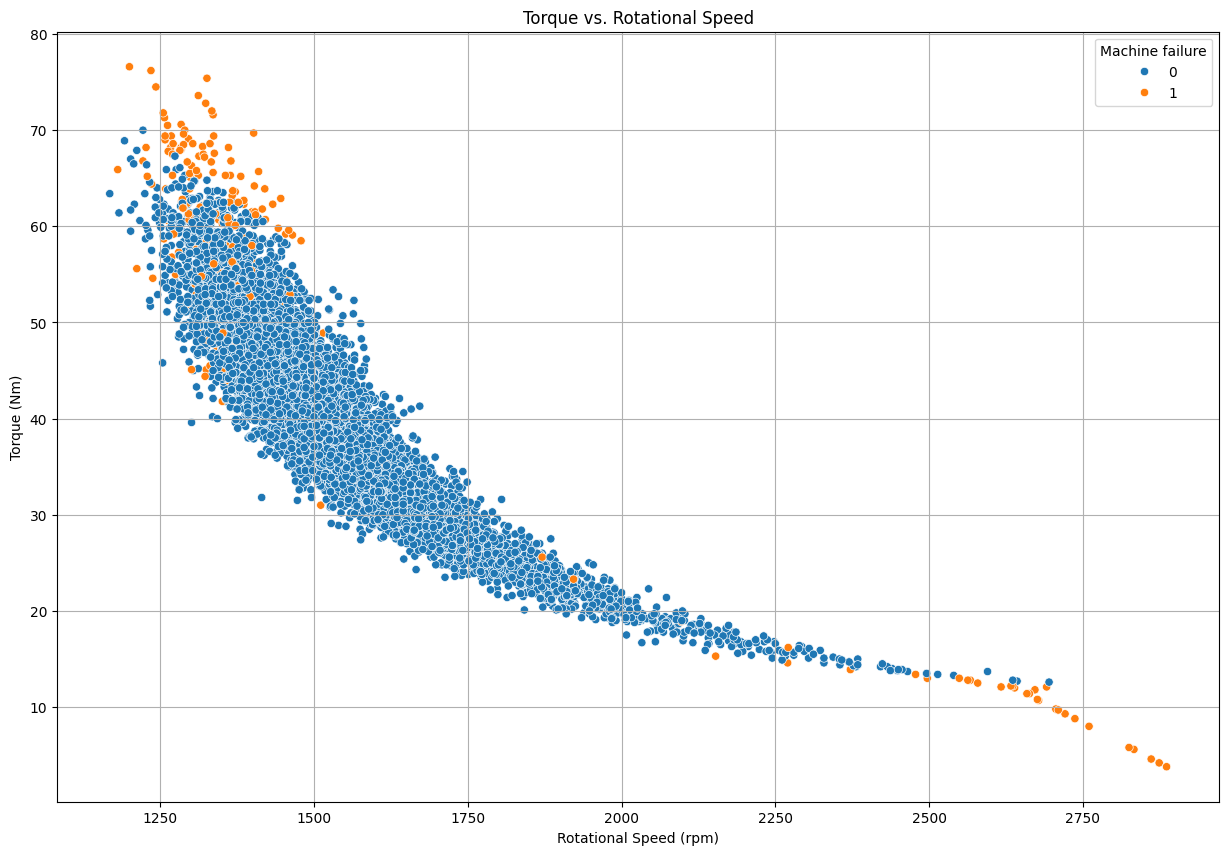

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', data=df)
plt.title('Torque vs. Rotational Speed')
plt.xlabel('Rotational Speed (rpm)')
plt.ylabel('Torque (Nm)')
plt.grid(True)
plt.show()
plt.savefig('failure_Torque_vs_Rotational_Speed')


## Deduction
The Upper Left Cluster: 
These failures occur when the machine is under massive load / High Torque and Low Rotational Speed. This likely represents Overstrain Failure (the motor literally can't handle the resistance).

The Bottom Right Tail: 
These failures happen at very high rpm and low Torque. This is often Tool Wear Failure or centrifugal instability.

The "Safe Zone": 
The blue mass in the middle is your stable operating region.